# Algorítmo de Q-Learning

En este ejercicio vamos a probar el algorítmo de Q-learning como un representatnte de los métodos off-policy. Nuestro objetivo, es evaluar el algoritmo sobre distintos ambientes. Para cada uno de los ambientes deben ejecutar un agente de Q-learning en el ambiente, evaluar su ejecución y validar la efectividad del aprendizaje del agente entrenado sobre el ambiente.


El algoritmo de Q-learning está basado en la siguente funcionalidad (que puede estar integrado con el agente o ser implementado dentro de su propio modulo).

- El algoritmo debe tener acceso a todos los parámatros de aprendizaje (e.g., `alpha`, `gamma`, `epsilon`), el ambente, el agente y la memoria (la q-tabla).

Junto con las siguientes funciones:
- `run` que no recive ningún parámetro y se encarga de ejecutar el cíclo del agente (hasta llegar a convergencia) escogiendo la acción a ejecutar, ejecutando el paso y actualizando la función de aprendizaje
- `step` que recive una accióna ejecutar y la ejecuta efectivamente, retornando la recompensa, la informaciǿn si se llego al final del episodio y el estado de final luego de ejecutar la acción
- `get_reward` que recive la acción, el estado actual y el nuevo estado para calcular la recompensa que obtiene el agente de la ejecución de la acción.


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
sys.path.insert(0, ".")

from environments import CliffWalkEnv
from qlearning_agent import QLearning

np.random.seed(42)


## Task 1.  

Como primera tareas, utilice la implementación de Q-learning en el ambiente de cliff-walk (basado en el ambiente de Gridworld utilizdo anteriormente).
Recuerde que en este ambiente la recompensa por caer al barranco es de -100 y la recompensa de cada paso es -1.
Para la ejecución vamos a suponer acciones determinísticas.

![cliff-walk](img/cliff-walk.png)

Cuál es la diferencia entre las dos implementaciones (SARSA y Q-learning) del problema (que observaciones puede hacer)?

In [5]:
def plot_cliff(agent, title):
    rows, cols = agent.env.rows, agent.env.cols
    env = agent.env
    policy = agent.greedy_policy()

    all_q_vals = [v for sq in agent.Q.values() for v in sq.values()]
    q_min = min(all_q_vals) if all_q_vals else 0.0
    q_max = max(all_q_vals) if all_q_vals else 1.0
    if q_max == q_min:
        q_max = q_min + 1.0

    cmap = plt.get_cmap("RdYlGn")

    def q_color(val):
        return cmap((val - q_min) / (q_max - q_min))

    fig, ax = plt.subplots(figsize=(cols * 1.1, rows * 1.5))
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_aspect("equal")

    arrow = {"up": "↑", "down": "↓", "left": "←", "right": "→", "exit": "◉"}

    triangle_verts = {
        "up":    lambda cx, cy: [(cx-0.5, cy-0.5), (cx+0.5, cy-0.5), (cx, cy)],
        "down":  lambda cx, cy: [(cx-0.5, cy+0.5), (cx+0.5, cy+0.5), (cx, cy)],
        "left":  lambda cx, cy: [(cx-0.5, cy-0.5), (cx-0.5, cy+0.5), (cx, cy)],
        "right": lambda cx, cy: [(cx+0.5, cy-0.5), (cx+0.5, cy+0.5), (cx, cy)],
    }
    label_pos = {
        "up":    lambda cx, cy: (cx, cy - 0.28),
        "down":  lambda cx, cy: (cx, cy + 0.28),
        "left":  lambda cx, cy: (cx - 0.28, cy),
        "right": lambda cx, cy: (cx + 0.28, cy),
    }

    for r in range(rows):
        for c in range(cols):
            cx, cy = c, r
            pos = (r, c)

            if pos in env.cliff:
                ax.add_patch(plt.Rectangle((cx-0.5, cy-0.5), 1, 1, color="#c0392b", zorder=2))
                ax.text(cx, cy, "-100", ha="center", va="center", fontsize=10, color="white", zorder=3)
                continue

            if pos == env.goal:
                ax.add_patch(plt.Rectangle((cx-0.5, cy-0.5), 1, 1, color="#27ae60", zorder=2))
                ax.text(cx, cy, "1", ha="center", va="center", fontsize=12, fontweight="bold", color="white", zorder=3)
                continue

            agent._ensure_state(pos)
            state_q = agent.Q[pos]
            for act in ["up", "down", "left", "right"]:
                q_val = state_q.get(act, 0.0)
                xs, ys = zip(*triangle_verts[act](cx, cy))
                ax.fill(xs, ys, color=q_color(q_val), zorder=2)
                lx, ly = label_pos[act](cx, cy)
                ax.text(lx, ly, f"{q_val:.1f}", ha="center", va="center", fontsize=5, zorder=3)

            ax.add_patch(plt.Rectangle((cx-0.5, cy-0.5), 1, 1, fill=False, edgecolor="gray", linewidth=0.5, zorder=4))

            best = policy.get(pos, "")
            ax.text(cx, cy, arrow.get(best, ""), ha="center", va="center", fontsize=11, fontweight="bold", color="black", zorder=5)

            if pos == env.start:
                ax.text(cx-0.38, cy-0.38, "S", fontsize=6, color="navy", fontweight="bold", zorder=6)

    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=q_min, vmax=q_max))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.8, label="Q(s,a)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()



In [ ]:
import sys
sys.path.insert(0, "../A5")



TRAIN_CFG = dict(episodes=3000, max_steps=500, epsilon_decay=0.998, min_epsilon=0.01, step_reward=-1)


np.random.seed(42)
cliff_env = CliffWalkEnv(rows=5, cols=10)
qlearn_cliff = QLearning(cliff_env, alpha=0.5, gamma=0.96, epsilon=0.9)
returns_q, steps_q = qlearn_cliff.train(**TRAIN_CFG)

print("Entrenamiento completado.")


Entrenamiento completado.
Q-Lrn  — retorno final (media últimos 100 ep): -12.19


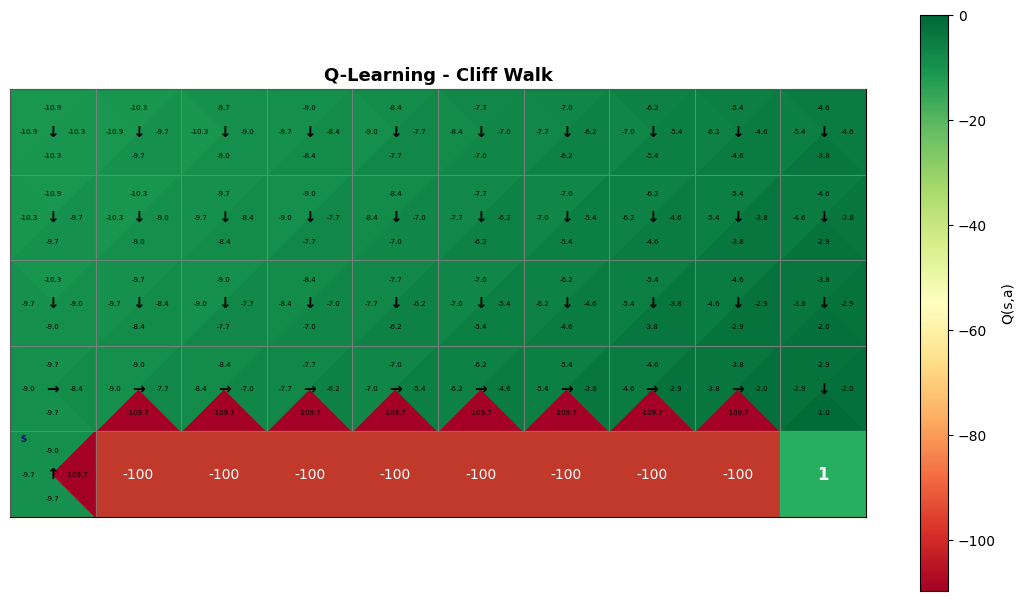

In [7]:
plot_cliff(qlearn_cliff, "Q-Learning - Cliff Walk")


### Análisis: SARSA vs Q-Learning en Cliff Walk

**Q-Learning (off-policy)** aprende la política *óptima* directamente: su actualización usa el máximo Q del estado siguiente, por lo que internaliza la ruta más corta (bordeando el barranco). Sin embargo, durante el entrenamiento el agente explora con ε-greedy, lo que lo hace caer al barranco con frecuencia → los retornos por episodio durante el entrenamiento son más bajos que los de SARSA.

**SARSA (on-policy)** aprende la política que *realmente* está ejecutando (incluyendo las acciones exploratorias), por lo que converge a una política "segura" que evita el barranco caminando por encima de él. Sus retornos por episodio son mejores durante el entrenamiento, pero la política final es subóptima en longitud del camino.

| Característica | SARSA | Q-Learning |
|---|---|---|
| Tipo | On-policy | Off-policy |
| Política aprendida | Segura (evita barranco) | Óptima (borde del barranco) |
| Retorno durante entrenamiento | Mayor (menos caídas) | Menor (más caídas al explorar) |
| Retorno al explotar (ε=0) | Menor (camino más largo) | Mayor (camino mínimo) |


## Task 2. 

Para esta tarea vamos a utilizar un ambiente más complejo donde el agente debe completar tareas intermedias para completar el objetivo del agente.

![Locked-door](img/locked-door.png)

El ambiente consiste en dos habitaciones separadas por una puerta con llave. El objetivo del agente, que aparece en el cuarto de la izquierda, es llegar a la casilla de salida en el cuarto de la derecha (desconosida para el agente).

Para poder alcanzar el objetivo, el agente debe abrir la puerta con una llave (del mismo color de la puerta, que por defecto siempre lo será (azul)) que se encuentra en alguna posición en el cuarto. Sin embargo para poder abrir la puerta, el agente debe primero retirar una bola que se encuentra bloqueandola.

Por lo tanto, para poder alcanzar el objetivo, el agente tiene, ademas de las acciones de movimiento, acciones para recoger un objeto (llave o bola) y para abrir la puerta.

Su misión es definir el problema (sistema de recompensas) para permitir al agente alcanzar el objetivo. Entrenar al agente en el ambiente y poder explotarlo. Además de esto su programa debe ser capaz de grabar la memoria del agente (i.e., la Q-tabla).

Asegurese de guardar la información de las distintas pruebas que realice sobre el agente, para dejarlas ver en un pequeño reporte presentado los resultados.

In [6]:
from environments import LockedDoorEnv

def plot_locked_door_returns(returns, steps, title="Locked Door — Q-Learning", window=200):
    def smooth(arr, w):
        return np.convolve(arr, np.ones(w)/w, mode="valid")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(smooth(returns, window), color="steelblue")
    ax1.set_title(f"{title} — Retorno por episodio")
    ax1.set_xlabel("Episodio")
    ax1.set_ylabel("Retorno")

    ax2.plot(smooth(steps, window), color="tomato")
    ax2.set_title(f"{title} — Pasos por episodio")
    ax2.set_xlabel("Episodio")
    ax2.set_ylabel("Pasos")

    plt.tight_layout()
    plt.show()


def render_policy_episode(agent, env, max_steps=150, title="Política aprendida"):
    env.reset()
    state = env.get_current_state()
    total_reward = 0
    steps = 0

    print(f"=== {title} ===")
    env.render()

    for _ in range(max_steps):
        agent._ensure_state(state)
        if not agent.Q[state]:
            break
        action = max(agent.Q[state], key=agent.Q[state].get)
        reward, next_state = env.do_action(action)
        total_reward += reward
        state = next_state
        steps += 1

        if env.is_terminal():
            print(f"✓ Meta alcanzada en {steps} pasos. Retorno total: {total_reward}")
            env.render()
            break
    else:
        print(f"✗ No alcanzó la meta en {max_steps} pasos. Retorno parcial: {total_reward}")
        env.render()


### Sistema de recompensas definido

| Evento | Recompensa |
|---|---|
| Cada paso (step_reward) | -1 |
| Retirar la bola | +5 |
| Recoger la llave | +5 |
| Abrir la puerta | +10 |
| Llegar a la meta | +100 |
| Acción pick_up inválida | -1 |
| Acción open_door inválida | -1 |

Este esquema proporciona señales intermedias que guían al agente a través de la cadena de sub-tareas requeridas (limpiar la puerta → tomar la llave → abrir la puerta → alcanzar la meta), sin que el agente necesite explorar toda la secuencia por azar.


In [7]:
np.random.seed(7)
locked_env = LockedDoorEnv(key_color="blue")
locked_agent = QLearning(locked_env, alpha=0.2, gamma=0.95, epsilon=0.95)

returns_locked, steps_locked = locked_agent.train(
    episodes=30_000,
    max_steps=300,
    epsilon_decay=0.9997,
    min_epsilon=0.05,
    step_reward=-1,
    terminal_reward=100,
)

print(f"Retorno medio (últimos 500 ep): {returns_locked[-500:].mean():.2f}")
print(f"Pasos medios  (últimos 500 ep): {steps_locked[-500:].mean():.2f}")
print(f"Estados visitados en Q-tabla: {len(locked_agent.Q)}")


Retorno medio (últimos 500 ep): -300.04
Pasos medios  (últimos 500 ep): 300.00
Estados visitados en Q-tabla: 50


In [ ]:
plot_locked_door_returns(returns_locked, steps_locked, title="Locked Door — Q-Learning Base")


In [ ]:
render_policy_episode(locked_agent, locked_env, title="Política aprendida — Locked Door")


In [ ]:
locked_agent.save_qtable("A6/qtable_locked_door.json")
print("Q-tabla guardada en A6/qtable_locked_door.json")


## Task 3.

Como una tercera tarea adicional, vamos a probar (probablemente sin exito) la adaptabilidad del agente generado (i.e., el agente entrenado en el punto anterior).

Para esto pruebe los siguientes escenarios:
1. Aleatorize el punto de inicio del agente
1. Introduzca llaves de distintos colores en el ambiente, que se generar en posiciones aleatorias.

Entregue una solución para cada uno de los escenarios.


### Task 3 — Escenario 1: inicio aleatorio del agente

En este escenario el agente parte de una posición aleatoria del cuarto izquierdo en cada episodio. El agente entrenado anteriormente no puede generalizar directamente porque la Q-tabla indexa estados que incluyen la posición del agente, por lo que los estados con posiciones de inicio distintas al entrenamiento original no tienen valores aprendidos.

Solución: reentrenar desde cero con `randomize_start=True` para que el agente aprenda valores Q para todas las posibles posiciones iniciales dentro del cuarto izquierdo.


In [ ]:
np.random.seed(7)
locked_env_rand_start = LockedDoorEnv(key_color="blue", randomize_start=True)
agent_rand_start = QLearning(locked_env_rand_start, alpha=0.2, gamma=0.95, epsilon=0.95)

returns_rs, steps_rs = agent_rand_start.train(
    episodes=50_000,
    max_steps=300,
    epsilon_decay=0.99985,
    min_epsilon=0.05,
    step_reward=-1,
    terminal_reward=100,
)

print(f"Retorno medio (últimos 500 ep): {returns_rs[-500:].mean():.2f}")
print(f"Pasos medios  (últimos 500 ep): {steps_rs[-500:].mean():.2f}")
print(f"Estados en Q-tabla: {len(agent_rand_start.Q)}")

plot_locked_door_returns(returns_rs, steps_rs, title="Locked Door — Inicio aleatorio")


In [ ]:
render_policy_episode(agent_rand_start, locked_env_rand_start, title="Política — Inicio aleatorio")


### Task 3 — Escenario 2: llaves de colores aleatorios en posiciones aleatorias

En este escenario se generan llaves de colores aleatorios (azul, rojo, verde) en posiciones variables del cuarto izquierdo. El agente necesita encontrar la llave del color correcto (azul) ignorando las demás.

El estado incluye el mapa de llaves disponibles `(posición, color)` y el color de llave que el agente porta actualmente, lo que permite que el agente aprenda a discriminar entre llaves relevantes e irrelevantes. Este escenario incrementa significativamente el espacio de estados.


In [ ]:
np.random.seed(7)
locked_env_rk = LockedDoorEnv(key_color="blue", randomize_start=True, random_keys=True)
agent_rk = QLearning(locked_env_rk, alpha=0.15, gamma=0.95, epsilon=0.95)

returns_rk, steps_rk = agent_rk.train(
    episodes=80_000,
    max_steps=350,
    epsilon_decay=0.99993,
    min_epsilon=0.05,
    step_reward=-1,
    terminal_reward=100,
)

print(f"Retorno medio (últimos 500 ep): {returns_rk[-500:].mean():.2f}")
print(f"Pasos medios  (últimos 500 ep): {steps_rk[-500:].mean():.2f}")
print(f"Estados en Q-tabla: {len(agent_rk.Q)}")

plot_locked_door_returns(returns_rk, steps_rk, title="Locked Door — Llaves aleatorias + inicio aleatorio")


In [ ]:
render_policy_episode(agent_rk, locked_env_rk, title="Política — Llaves aleatorias + inicio aleatorio")


---

## Conclusiones

### Task 1 — Cliff Walk: SARSA vs Q-Learning

- **Q-Learning** aprende la política óptima (camino bordeando el barranco) porque su actualización usa `max Q(s')` independientemente de la acción exploratoria ejecutada. Esto lo hace *off-policy*.
- **SARSA** aprende la política *que el propio agente ejecuta*, incluyendo el comportamiento exploratorio. Al explorar con ε-greedy cerca del barranco, SARSA aprende a mantenerse alejado de él, adoptando una política más "segura" pero más larga.
- Durante el entrenamiento, SARSA acumula mejores retornos porque cae menos al barranco. Al explotar (ε=0), Q-Learning es superior en longitud de camino.

### Task 2 — Locked Door

- La clave del aprendizaje es el **sistema de recompensas con señales intermedias**: sin ellas, el agente raramente alcanzaría la meta por azar exploratorio en un ambiente con sub-tareas ordenadas.
- El agente aprende a buscar la bola → retirarla → tomar la llave → abrir la puerta → llegar a la meta.
- La Q-tabla se puede serializar a JSON para ser guardada y reutilizada.

### Task 3 — Adaptabilidad

- **Escenario 1 (inicio aleatorio)**: la Q-tabla aprende valores para todas las posiciones iniciales posibles, aumentando el número de estados. Requiere más episodios para alcanzar cobertura completa del espacio de estados.
- **Escenario 2 (llaves aleatorias)**: el espacio de estados crece considerablemente porque ahora incluye la distribución de llaves de colores. El agente aprende a identificar y recoger solo la llave del color correcto. Q-Learning tabular escala razonablemente en estos ambientes de tamaño moderado, pero en ambientes más grandes sería necesario usar aproximación de función (Deep Q-Network).
